# Diabetes Prediction — Linear SVM **from scratch**


## 1. Importing the Dependencies

No `sklearn` this time — just NumPy, pandas, and matplotlib for the convergence plot.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Data Collection and Analysis

PIMA Diabetes Dataset

In [4]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv("C:/Users/JONATHAN/Downloads/python/Data/Machine Leraning/practical learning videos/diabetes.csv")


In [6]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
# number of rows and columns in this dataset
diabetes_dataset.shape


(768, 9)

In [10]:
# getting the statistical measures of the data
diabetes_dataset.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

0 --> Non-Diabetic

1 --> Diabetic

In [14]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [16]:
# separating the data and labels
X = diabetes_dataset.drop(columns='Outcome', axis=1).values   # straight to NumPy
Y = diabetes_dataset['Outcome'].values


In [18]:
print(X)

[[  6.    148.     72.    ...  33.6     0.627  50.   ]
 [  1.     85.     66.    ...  26.6     0.351  31.   ]
 [  8.    183.     64.    ...  23.3     0.672  32.   ]
 ...
 [  5.    121.     72.    ...  26.2     0.245  30.   ]
 [  1.    126.     60.    ...  30.1     0.349  47.   ]
 [  1.     93.     70.    ...  30.4     0.315  23.   ]]


In [20]:
print(Y)

[1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1
 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0
 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1 0 0
 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0 0 0 1
 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 0 1
 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 1 0 0 1 0 1 1 0 1 0 1 0 1
 0 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 1 1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 

## 3. Data Standardization

`StandardScaler` just computes each column's mean and standard deviation, then rescales. We write that ourselves — same idea, same formula: $z = \frac{x - \mu}{\sigma}$.

In [22]:
def standardize_fit(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1  # guard against divide-by-zero on constant columns
    return mean, std

def standardize_apply(X, mean, std):
    return (X - mean) / std


In [24]:
scaler_mean, scaler_std = standardize_fit(X)
standardized_data = standardize_apply(X, scaler_mean, scaler_std)


In [26]:
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [28]:
X = standardized_data
Y = diabetes_dataset['Outcome'].values


In [30]:
print(X)
print(Y)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
[1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1
 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0 0 0

## 4. Train Test Split


In [32]:
def train_test_split_scratch(X, y, test_size=0.2, random_state=2):
    """
    Stratified train/test split, implemented from scratch.
    Splits each class separately so the class ratio is preserved in both sets,
    then shuffles and recombines.
    """
    rng = np.random.RandomState(random_state)
    train_idx, test_idx = [], []

    for c in np.unique(y):
        c_idx = np.where(y == c)[0]
        rng.shuffle(c_idx)
        n_test = int(round(len(c_idx) * test_size))
        test_idx.extend(c_idx[:n_test])
        train_idx.extend(c_idx[n_test:])

    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


In [36]:
X_train, X_test, Y_train, Y_test = train_test_split_scratch(X, Y, test_size=0.2, random_state=2)


In [38]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


## 5. Linear SVM — built from scratch

A linear-kernel SVM finds a hyperplane $w \cdot x + b = 0$ that separates the two classes with the widest possible margin, while tolerating some violations (soft margin). SVM math uses labels in $\{-1, +1\}$ rather than $\{0, 1\}$, so that's the first thing we convert.

**Objective (soft-margin, primal form):**
$$J(w,b) = \frac{1}{2}\|w\|^2 + C\cdot\frac{1}{m}\sum_{i=1}^{m}\max\big(0,\ 1 - y^{(i)}(w\cdot x^{(i)}+b)\big)$$

The first term is the margin-widening regularizer; the second is the **hinge loss**, which only penalizes points that are inside the margin or misclassified. `C` controls the trade-off between a wide margin and fewer violations.

In [40]:
# relabel Outcome from {0, 1} to {-1, +1} for the SVM formulation
Y_train_svm = np.where(Y_train == 0, -1, 1)
Y_test_svm = np.where(Y_test == 0, -1, 1)


### 5.1 Initializing parameters

In [42]:
def initialize_parameters(n_features):
    w = np.zeros(n_features)
    b = 0.0
    return w, b


### 5.2 The hinge-loss objective

Used only to track progress (like the cost function in logistic regression) — it's not needed to compute the gradients.

In [44]:
def compute_cost(X, y, w, b, C):
    m = X.shape[0]
    margins = y * (np.dot(X, w) + b)
    hinge_loss = np.maximum(0, 1 - margins)
    cost = 0.5 * np.dot(w, w) + C * (1 / m) * np.sum(hinge_loss)
    return cost


### 5.3 The gradients (subgradients)

The hinge loss isn't differentiable exactly at the margin, so we use a **subgradient**: a point only contributes to the gradient if it violates the margin ($y^{(i)}(w\cdot x^{(i)}+b) < 1$); otherwise only the regularization term applies.

$$\frac{\partial J}{\partial w} = w - C\cdot\frac{1}{m}\sum_{i:\ \text{violated}} y^{(i)}x^{(i)} \qquad \frac{\partial J}{\partial b} = -C\cdot\frac{1}{m}\sum_{i:\ \text{violated}} y^{(i)}$$

In [46]:
def compute_gradients(X, y, w, b, C):
    m = X.shape[0]
    margins = y * (np.dot(X, w) + b)
    violated = margins < 1   # boolean mask: which points are inside the margin / misclassified

    dw = w - C * (1 / m) * np.dot(X[violated].T, y[violated])
    db = -C * (1 / m) * np.sum(y[violated])
    return dw, db


### 5.4 Gradient descent

Same loop structure as before: step the parameters against the gradient, track the cost periodically.

In [48]:
def gradient_descent(X, y, w, b, C, learning_rate, num_iterations, print_every=200):
    cost_history = []

    for i in range(num_iterations):
        dw, db = compute_gradients(X, y, w, b, C)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % print_every == 0 or i == num_iterations - 1:
            cost = compute_cost(X, y, w, b, C)
            cost_history.append((i, cost))
            print(f'Iteration {i:5d} | Cost: {cost:.6f}')

    return w, b, cost_history


### 5.5 Prediction

The decision function is just $w\cdot x + b$; its sign tells us which side of the hyperplane a point falls on.

In [50]:
def decision_function(X, w, b):
    return np.dot(X, w) + b

def predict(X, w, b):
    # returns -1 / +1, matching the SVM label convention
    return np.sign(decision_function(X, w, b))


### 5.6 Accuracy metric

In [54]:
def accuracy_score_scratch(y_true, y_pred):
    return np.mean(y_true == y_pred)


## 6. Training the Model


In [200]:
n_features = X_train.shape[1]
w, b = initialize_parameters(n_features)

C = 0.2
learning_rate = 0.00001
num_iterations = 5000

w, b, cost_history = gradient_descent(X_train, Y_train_svm, w, b, C, learning_rate, num_iterations)


Iteration     0 | Cost: 0.200000
Iteration   200 | Cost: 0.199956
Iteration   400 | Cost: 0.199911
Iteration   600 | Cost: 0.199868
Iteration   800 | Cost: 0.199824
Iteration  1000 | Cost: 0.199780
Iteration  1200 | Cost: 0.199737
Iteration  1400 | Cost: 0.199693
Iteration  1600 | Cost: 0.199650
Iteration  1800 | Cost: 0.199607
Iteration  2000 | Cost: 0.199564
Iteration  2200 | Cost: 0.199521
Iteration  2400 | Cost: 0.199479
Iteration  2600 | Cost: 0.199436
Iteration  2800 | Cost: 0.199394
Iteration  3000 | Cost: 0.199352
Iteration  3200 | Cost: 0.199310
Iteration  3400 | Cost: 0.199268
Iteration  3600 | Cost: 0.199226
Iteration  3800 | Cost: 0.199184
Iteration  4000 | Cost: 0.199143
Iteration  4200 | Cost: 0.199101
Iteration  4400 | Cost: 0.199060
Iteration  4600 | Cost: 0.199019
Iteration  4800 | Cost: 0.198978
Iteration  4999 | Cost: 0.198937


In [202]:
print("Final bias (b):", b)
print("Final weights (w):")
print(w)

print("\nCost history (iteration, cost):")
for i, c in cost_history:
    print(f'  Iteration {i:5d} -> Cost: {c:.6f}')


Final bias (b): -0.0030293159609121613
Final weights (w):
[0.00217098 0.00454007 0.0006214  0.00063157 0.00128155 0.00252865
 0.00162229 0.00267751]

Cost history (iteration, cost):
  Iteration     0 -> Cost: 0.200000
  Iteration   200 -> Cost: 0.199956
  Iteration   400 -> Cost: 0.199911
  Iteration   600 -> Cost: 0.199868
  Iteration   800 -> Cost: 0.199824
  Iteration  1000 -> Cost: 0.199780
  Iteration  1200 -> Cost: 0.199737
  Iteration  1400 -> Cost: 0.199693
  Iteration  1600 -> Cost: 0.199650
  Iteration  1800 -> Cost: 0.199607
  Iteration  2000 -> Cost: 0.199564
  Iteration  2200 -> Cost: 0.199521
  Iteration  2400 -> Cost: 0.199479
  Iteration  2600 -> Cost: 0.199436
  Iteration  2800 -> Cost: 0.199394
  Iteration  3000 -> Cost: 0.199352
  Iteration  3200 -> Cost: 0.199310
  Iteration  3400 -> Cost: 0.199268
  Iteration  3600 -> Cost: 0.199226
  Iteration  3800 -> Cost: 0.199184
  Iteration  4000 -> Cost: 0.199143
  Iteration  4200 -> Cost: 0.199101
  Iteration  4400 -> Cost:

### Visualizing convergence

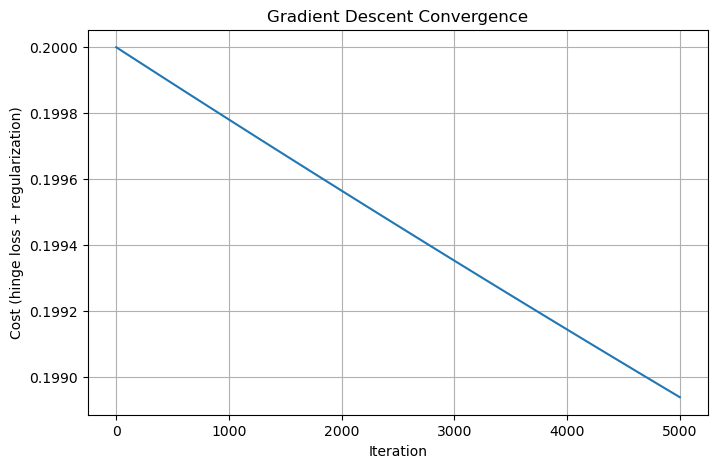

In [204]:
iterations, costs = zip(*cost_history)
plt.figure(figsize=(8, 5))
plt.plot(iterations, costs)
plt.xlabel('Iteration')
plt.ylabel('Cost (hinge loss + regularization)')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.show()


## 7. Model Evaluation

### Accuracy Score

In [206]:
# accuracy score on the training data
X_train_prediction = predict(X_train, w, b)
training_data_accuracy = accuracy_score_scratch(Y_train_svm, X_train_prediction)


In [208]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.754071661237785


In [210]:
# accuracy score on the test data
X_test_prediction = predict(X_test, w, b)
test_data_accuracy = accuracy_score_scratch(Y_test_svm, X_test_prediction)


In [212]:
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.7272727272727273


## 8. Making a Predictive System


In [214]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# standardize the input data using the SAME mean/std computed on the training data
std_data = standardize_apply(input_data_reshaped, scaler_mean, scaler_std)
print(std_data)

prediction = predict(std_data, w, b)
print(prediction)

if prediction[0] == -1:
    print('The person is not diabetic')
else:
    print('The person is diabetic')


[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1.]
The person is diabetic


## 9. (Optional) Compare against sklearn

Uncomment and run to sanity-check your from-scratch SVM against sklearn's — accuracies should be close, though not necessarily identical since sklearn's `SVC` solves the dual problem exactly rather than approximating it with gradient descent.

In [ ]:
# from sklearn import svm
# from sklearn.metrics import accuracy_score
#
# sk_classifier = svm.SVC(kernel='linear')
# sk_classifier.fit(X_train, Y_train)
# print('sklearn train accuracy:', accuracy_score(Y_train, sk_classifier.predict(X_train)))
# print('sklearn test accuracy:', accuracy_score(Y_test, sk_classifier.predict(X_test)))
